# Multi-Fidelity SCBO Optimization on Borehole8 Function
This notebook demonstrates how to run a multi-fidelity SCBO optimization using the `mfscbo` package on the Borehole8 benchmark function.

In [1]:
# Import necessary libraries
from mfscbo.functions import Borehole8
from mfscbo.mfscbo_optimization import ScboMfOptimizer
from mfscbo.plot import plot_rhos, plot_noises, plot_bestYs, plot_nbiters, plot_tr_lengths
from mfscbo.utils import eval_fun_unnormalized
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

/home/lpalazzo/Documents/These/BayesianOC/matlab_env_boc/lib64/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Define torch arguments
torchargs = {
    "device": "cpu",
    "dtype": torch.double
}

In [3]:
# Define evaluation objectives at different fidelities
f0_ = Borehole8(fidelity=0, torchargs=torchargs)
f1_ = Borehole8(fidelity=1, torchargs=torchargs)

# Define bounds and dimension
bounds = f0_.bounds
dim = bounds.shape[1]

# Convert to maximization problem (SCBO expects maximization) and unnormalize
f0 = lambda x: -eval_fun_unnormalized(x, f0_, bounds)[:, None]  # shape (N,1)
f1 = lambda x: -eval_fun_unnormalized(x, f1_, bounds)[:, None]  # shape (N,1)
eval_objectives = [f0, f1]

In [4]:
# Define constraints (none in this case)
constraints = lambda x: (x[:,0]*0)[:, None]  # shape (N,1)

In [5]:
# Define number of initial points, rhos, and costs
n_pts = [28, 4]  # total 4*dim = 28+4=32
rhos = [1, 1]
costs = [1, 20]

In [6]:
# Initialize and run the SCBO optimizer
optimizer = ScboMfOptimizer(
    eval_objectives=eval_objectives,
    constraints=constraints,
    rhos=rhos,
    costs=costs,
    dim=dim,
    n_pts=n_pts,
    bounds=bounds,
    type_of_batch="sequential",
    type_of_centering="evaluated",
    torchargs=torchargs,
    restart=True,
    test=True  # Predictive mode
)
optimizer.initialize()
optimizer.optimize(max_cost=2000, batch_size=8, path="results/Borehole8", verbose=True)

Starting MF-SCBO optimization...
Max cost : 2000
Batch size : 8
Path : results/Borehole8

======================================================== Parameters for MF-SCBO Optimization =========================================================
______________________________________________________________________________________________________________________________________________________
| Parameter         | Value                                                                                                                          |
------------------------------------------------------------------------------------------------------------------------------------------------------
| dim               | 8                                                                                                                              |
| bounds            | [[0.05, 100.0, 63070.0, 990.0, 63.1, 700.0, 1120.0, 9855.0], [0.15, 50000.0, 115600.0, 1110.0, 116.0, 820.0, 1680.0, 12045.0]] |
| nb

In [7]:
# Load results
data = np.load("results/Borehole8/MFSCBO_data.npz", allow_pickle=True)
gps_info = data["gps_info"]
iterations = data["iterations"]
xvalues = data["cost_iter"]
bestY = data["best_Y"]
nbiters = data["nb_iter"]
tr_lengths = data["trust_region_lengths"]

In [8]:
# Post-process rhos
rhos = [[1] for _ in range(len(gps_info)-1)]  # no rho for fidelity 0
for fid in range(1, len(gps_info)):
    for it in range(len(iterations)-1):
        rhos[fid-1].append(gps_info[fid][it]["rho"])

# Post-process noises
noises = [[] for _ in range(len(gps_info))]
for fid in range(len(gps_info)):
    for it in range(len(iterations)-1):
        noises[fid].append(gps_info[fid][it]["noise"])

/tmp/ipykernel_2403142/1625047936.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax5.legend()


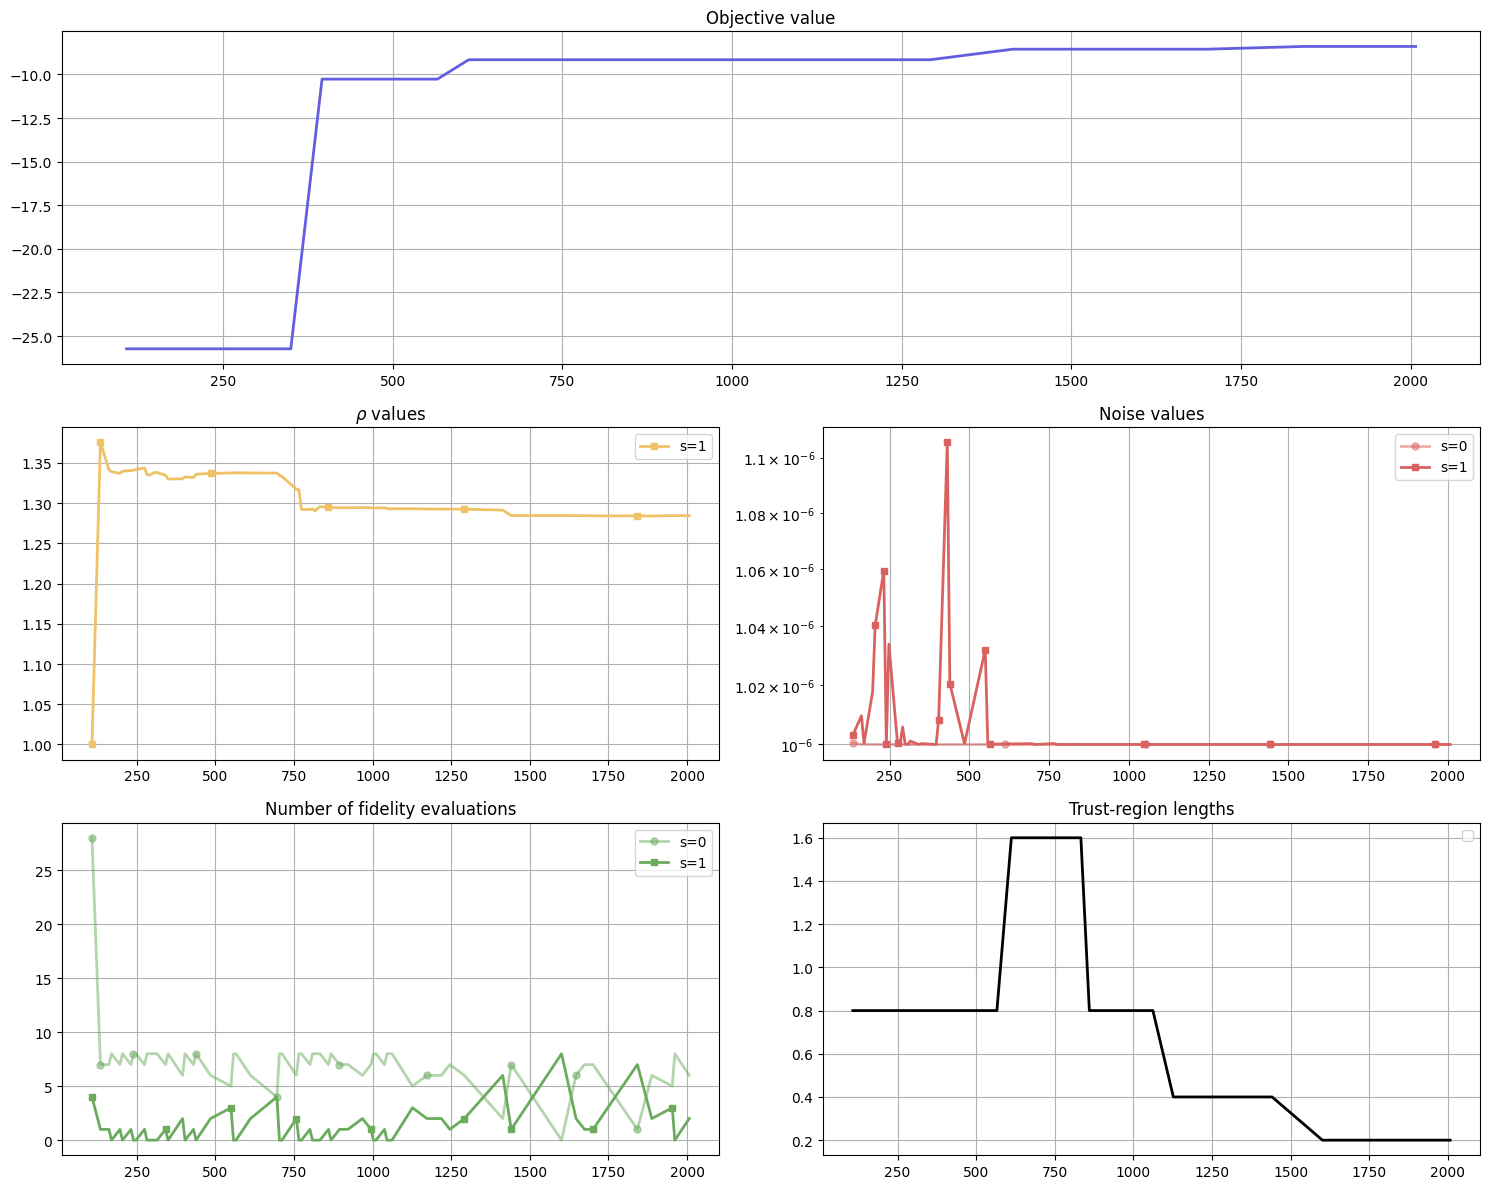

In [9]:
# Plot results
fig = plt.figure(figsize=(15,12))
gs = GridSpec(3, 2, figure=fig)
ax1 = fig.add_subplot(gs[0,:])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[2,0])
ax5 = fig.add_subplot(gs[2,1])

plot_bestYs(bestY, xvalues, ax=ax1)
plot_rhos(rhos, xvalues, ax=ax2)
plot_noises(noises, xvalues[1:], ax=ax3)
plot_nbiters(nbiters, xvalues, ax=ax4)
plot_tr_lengths(tr_lengths, xvalues, ax=ax5)

# Set titles, legends, and grids
ax1.set_title("Objective value")
ax1.grid()
ax2.set_title(r"$\rho$ values")
ax2.legend()
ax2.grid()
ax3.set_title("Noise values")
ax3.legend()
ax3.grid()
ax3.set_yscale("log")
ax4.set_title("Number of fidelity evaluations")
ax4.legend()
ax4.grid()
ax5.set_title("Trust-region lengths")
ax5.legend()
ax5.grid()

plt.tight_layout()
plt.savefig("results/Borehole8/MFSCBO_plots.pdf")
plt.show()